In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [ ]:
df_original = pd.read_csv('/content/drive/MyDrive/car_prices.csv', on_bad_lines='skip')
df = df_original.copy()

In [ ]:
df = df.drop(['vin', 'seller', 'saledate', 'state'], axis=1)

In [ ]:
df = df.dropna()

In [ ]:
Q1 = df['sellingprice'].quantile(0.25)
Q3 = df['sellingprice'].quantile(0.75)
IQR = Q3 - Q1
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 * 1.5 * IQR
df_temiz = df[(df['sellingprice'] >= alt_sinir) & (df['sellingprice'] <= ust_sinir)]

In [ ]:
df = df[df['sellingprice'] > 500]
df = df[df['odometer'] < 500000]

In [ ]:
Q1 = df['sellingprice'].quantile(0.25)
Q3 = df['sellingprice'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['sellingprice'] >= Q1 - 1.5 * IQR) & (df['sellingprice'] <= Q3 + 1.5 * IQR)]

In [ ]:
kategorik_sutunlar = ['make', 'model', 'trim', 'body', 'color', 'interior',]

In [ ]:
le = LabelEncoder()
for sutun in kategorik_sutunlar:
    df[sutun] = le.fit_transform(df[sutun].astype(str))

In [ ]:
X = df.drop(['sellingprice', 'mmr', 'transmission','condition'], axis=1)
y = df['sellingprice']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # Normalizasyon yapiyoruz

In [ ]:
rf_final = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_jobs=-1, random_state=42)

In [ ]:
rf_pred = rf_final.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest R2 Skoru: {rf_r2:.4f}")
print(f"Yüzde Karşılığı: %{rf_r2 * 100:.2f}")

Random Forest R2 Skoru: 0.9189
Yüzde Karşılığı: %91.89


In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [ ]:
lr_r2 = r2_score(y_test, lr_pred)
print(f"Linear Regression R2 Skoru: {lr_r2:.4f}")
print(f"Yüzde Karşılığı: %{lr_r2 * 100:.2f}")

Linear Regression R2 Skoru: 0.4656
Yüzde Karşılığı: %46.56


In [ ]:
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

In [ ]:
xgb_pred = xgb_model.predict(X_test)
print("XGBoost R2 Skoru:", r2_score(y_test, xgb_pred))

XGBoost R2 Skoru: 0.8851316222690977


In [ ]:

lr_mae = mean_absolute_error(y_test, lr_pred)

xgb_mae = mean_absolute_error(y_test, xgb_pred)

rf_mae = mean_absolute_error(y_test, rf_pred)

print("--- MODELLERİN ORTALAMA HATA PAYLARI (MAE) ---")
print(f"Linear Regression MAE : {lr_mae:.2f} $")
print(f"XGBoost MAE           : {xgb_mae:.2f} $")
print(f"Random Forest MAE     : {rf_mae:.2f} $")

--- MODELLERİN ORTALAMA HATA PAYLARI (MAE) ---
Linear Regression MAE : 4324.47 $
XGBoost MAE           : 1773.06 $
Random Forest MAE     : 1445.52 $


In [ ]:
y_pred = rf_final.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\n--- MCBÜ BÜYÜK VERİ ANALİSTİ BİTİRME PROJESİ RAPORU ---")
print(f"Model Başarı Oranı (R2): %{r2*100:.2f}")
print(f"Ortalama Hata Payı (MAE): {mae:.2f} $")


--- MCBÜ BÜYÜK VERİ ANALİSTİ BİTİRME PROJESİ RAPORU ---
Model Başarı Oranı (R2): %91.89
Ortalama Hata Payı (MAE): 1445.52 $


In [ ]:
train_score = rf_final.score(X_train, y_train)
test_score = rf_final.score(X_test, y_test)

print(f"Eğitim (Train) Başarısı: %{train_score*100:.2f}")
print(f"Test Başarısı: %{test_score*100:.2f}")

if (train_score - test_score) > 0.05:
    print("Sonuç: Model biraz ezberlemiş.")
else:
    print("Sonuç: Model ezberlememiş, genelleme yapabiliyor.")

Eğitim (Train) Başarısı: %93.65
Test Başarısı: %91.89
Sonuç: Model ezberlememiş, genelleme yapabiliyor.


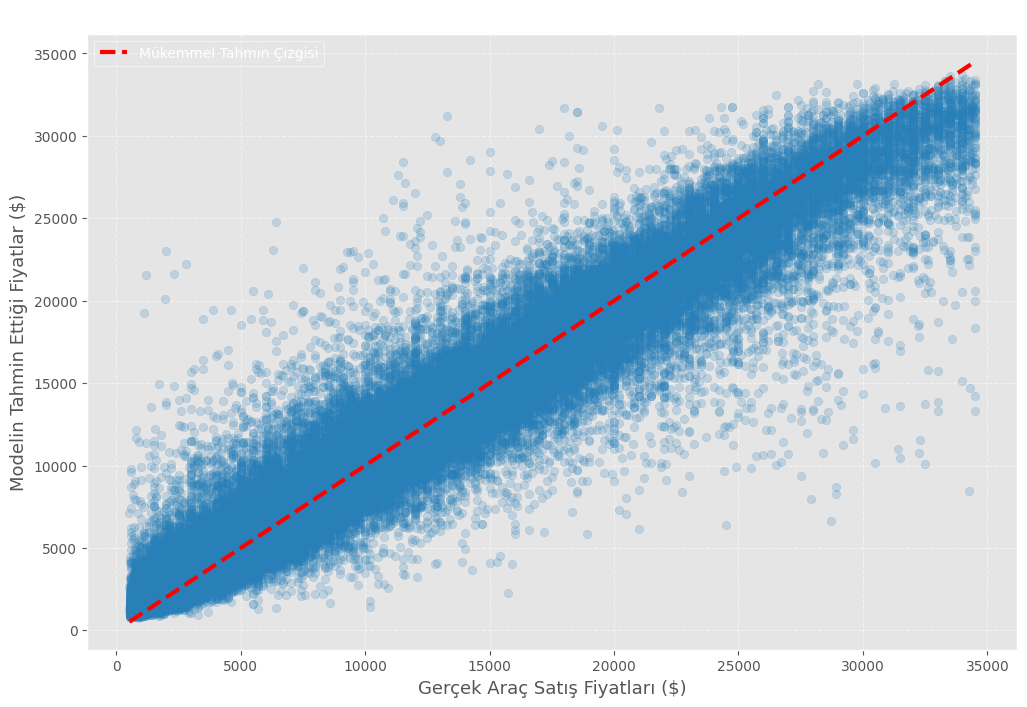

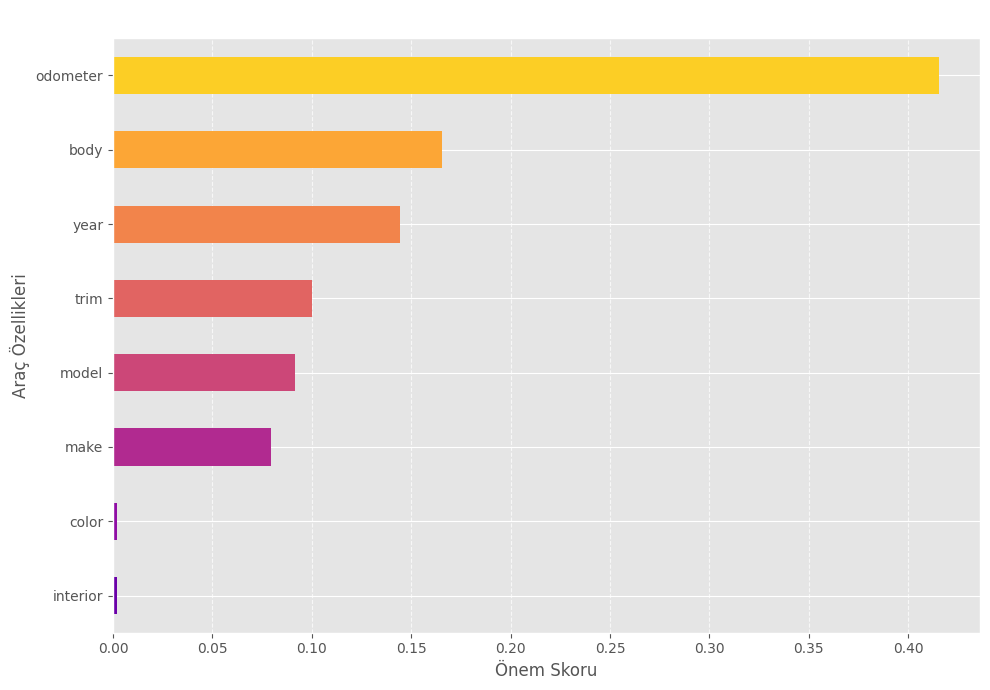

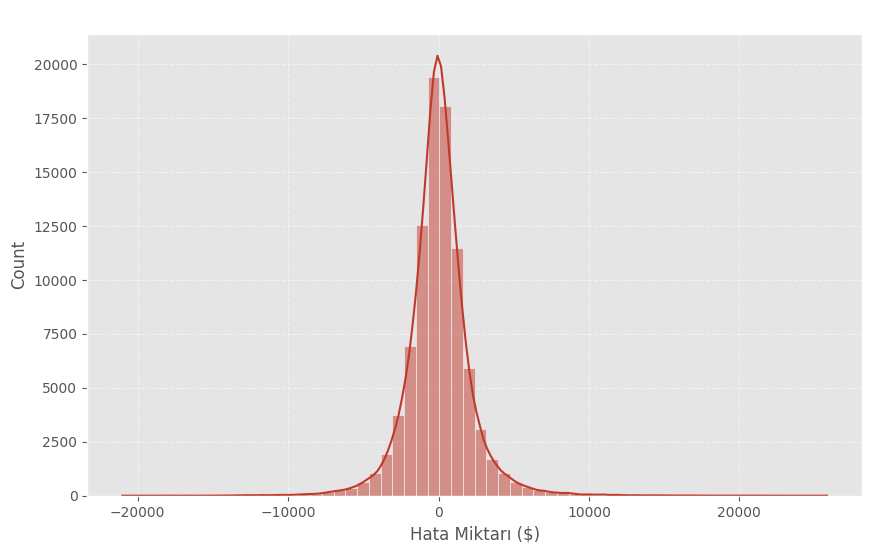

In [ ]:
plt.style.use('ggplot')
plt.rcParams['figure.facecolor'] = 'white'


# GÖRSEL 1: Gerçek vs Tahmin (Başarı Grafiği)
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_pred, alpha=0.2, color='#2980b9')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3, label='Mükemmel Tahmin Çizgisi')
plt.xlabel('Gerçek Araç Satış Fiyatları ($)', fontsize=13)
plt.ylabel('Modelin Tahmin Ettiği Fiyatlar ($)', fontsize=13)
plt.title('Tahmin Başarısı (Gerçek vs Tahmin)', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show() # Grafiği göster


# GÖRSEL 2: Özellik Önem Sıralaması (Fiyatı Ne Etkiliyor?)
importances = rf_final.feature_importances_
features = X.columns
feat_importances = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(feat_importances)))
feat_importances.plot(kind='barh', color=colors)
plt.title('Araç Fiyatını Belirleyen En Kritik Özellikler', fontsize=15, fontweight='bold')
plt.xlabel('Önem Skoru', fontsize=12)
plt.ylabel('Araç Özellikleri', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# GÖRSEL 3: Hata Payı Dağılımı (Residuals Plot)
plt.figure(figsize=(10, 6))
errors = y_test - y_pred
sns.histplot(errors, bins=60, kde=True, color='#c0392b')
plt.xlabel('Hata Miktarı ($)', fontsize=12)
plt.title('Tahmin Hatalarının Dağılımı (Sıfıra Yakınlık)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()